# Task 8: Time Series Prediction using LSTM on the AgriWebb Dataset

This notebook covers the complete sequence-to-sequence forecasting pipeline:
1. Environment Setup & Data Loading
2. Preprocessing & Sequence Standardization (Reserving last 5 timesteps for testing)
3. Model 1: Univariate LSTM (Lookback = 5, Predict = 5), including hyperparameter tuning
4. Model 2: Univariate LSTM (Lookback = 10, Predict = 5)
5. Model 3: Multivariate LSTM (TSDM + Climate Features, Flexible Lookback)
6. Comparative Evaluation (RMSE & R² Metrics and Loss Convergence Analysis)
7. Additional Diagnostics (per-paddock error breakdown and distribution-shift check)

## 1. Environment Setup & Library Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, r2_score
from torch.utils.data import DataLoader, TensorDataset, random_split
from torch.nn.utils.rnn import pack_padded_sequence

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 2. Data Preprocessing & Sequence Standardization

**Preprocessing steps and why each one matters:**

1. **Parse dates and sort by `PADDOCK_ID` then `OBSERVATION_DATE`.** Sequence models depend on chronological order; if rows were shuffled or out of order, "past" and "future" would be mixed and every downstream sequence/target pair would be meaningless.
2. **Group by paddock and exclude paddocks whose full series length is `<= lookback + test_steps`.** Every paddock needs enough history to form at least one training window *and* still hold back the last 5 timesteps for testing. A paddock without enough rows would either produce a training sequence built entirely from padding or leave no real test window at all — including it would just inject noise, not signal. This also standardises the usable paddocks: every paddock that survives is guaranteed at least one full-length, non-degenerate training sequence.
3. **Reserve the last 5 timesteps of every paddock as a held-out test set, per paddock, before scaling.** Splitting at the end of each series is the correct way to evaluate a forecasting model — a random row-wise split would let the model "see the future" of a paddock during training and leak information into the test window. Because each paddock has its own timeline, the split has to be applied per paddock, not once globally.
4. **Fit a separate `StandardScaler` per paddock on the training portion only, then apply it to that paddock's test portion.** TSDM and the climate variables live on very different absolute scales across paddocks (e.g. mean TSDM ranges from roughly 960 to 1700 across paddocks) and on different units from each other (rainfall vs. temperature vs. radiation). Standardising puts every feature on a comparable scale, which matters for LSTM training stability and convergence. Fitting the scaler on the train split only (never on the test split) avoids leaking test-set statistics into preprocessing.
5. **Build fixed-length, padded input windows per sample (`create_sequences`) and track each window's true (unpadded) length.** A batch tensor requires every sample to have the same shape, but the amount of real history available grows over the course of each paddock's series (e.g. only one timestep of history exists right after a paddock's series starts). Left-padding short windows with zeros and recording the true length lets `pack_padded_sequence` tell the LSTM exactly how much of each window is real data versus padding, so the padding never contaminates the learned representation.

In [2]:
# Load TSDM dataset
df = pd.read_csv('TSDM.csv')
print("Dataset shape:", df.shape)
print(df.head())

df['OBSERVATION_DATE'] = pd.to_datetime(df['OBSERVATION_DATE'])
df = df.sort_values(['PADDOCK_ID', 'OBSERVATION_DATE']).reset_index(drop=True)

paddock_col = 'PADDOCK_ID'
tsdm_col = 'TSDM'

Dataset shape: (3691, 10)
                                          PADDOCK_ID  ... 15D_AVG_RADIATION
0  d54f90a4aba145794a09808f912b5c02a413b054d26a3b...  ...         24.833333
1  d54f90a4aba145794a09808f912b5c02a413b054d26a3b...  ...         25.033333
2  d54f90a4aba145794a09808f912b5c02a413b054d26a3b...  ...         21.200000
3  d54f90a4aba145794a09808f912b5c02a413b054d26a3b...  ...         20.900000
4  d54f90a4aba145794a09808f912b5c02a413b054d26a3b...  ...         19.573333

[5 rows x 10 columns]


In [3]:
# Sequence creation function for multi-step sequence-to-sequence forecasting
def create_sequences(sequence, lookback, forecast_horizon, target_col):
    T, num_features = sequence.shape
    X, y, lengths = [], [], []
    pad_vector = np.zeros((lookback, num_features))

    for t in range(1, T - forecast_horizon + 1):
        context = sequence[:t]
        if len(context) > lookback:
            context = context[-lookback:]

        padded_context = pad_vector.copy()
        padded_context[-len(context):] = context

        X.append(padded_context)
        y.append(sequence[t:t + forecast_horizon, target_col])
        lengths.append(min(len(context), lookback))

    return np.array(X), np.array(y), lengths

In [4]:
def prepare_tsdm_data(df, feature_cols, lookback, test_steps=5, target_col=0):
    X_all, y_all, lengths_all, paddock_ids_all = [], [], [], []
    train_data, test_data = [], []

    for paddock_id, group in df.groupby(paddock_col):
        feature_values = group[feature_cols].values

        # Exclude paddocks with sequences shorter than required lookback + test steps
        min_required = lookback + test_steps
        if len(feature_values) <= min_required:
            continue

        # Reserve the last 5 timesteps of each paddock for testing
        scaler = StandardScaler()
        train_sample = scaler.fit_transform(feature_values[:-test_steps])
        test_sample = scaler.transform(feature_values[-test_steps:])

        train_data.append((paddock_id, train_sample))
        test_data.append((paddock_id, test_sample, scaler))

        # Generate training sequences
        X_loc, y_loc, lengths = create_sequences(train_sample, lookback, test_steps, target_col)
        if len(X_loc) > 0:
            X_all.append(X_loc)
            y_all.append(y_loc)
            lengths_all.extend(lengths)
            paddock_ids_all.extend([paddock_id] * len(X_loc))

    X_all = np.concatenate(X_all, axis=0)
    y_all = np.concatenate(y_all, axis=0)
    lengths_all = np.array(lengths_all)

    # paddock_ids_all lets us look up the right per-paddock scaler for every
    # training row later, so training metrics can be inverse-transformed back
    # to original TSDM units on the same scale as the test metrics.
    return torch.Tensor(X_all), torch.Tensor(y_all), torch.Tensor(lengths_all), paddock_ids_all, train_data, test_data

## 3. LSTM Network Architecture Definition

In [5]:
class SequenceLSTM(nn.Module):
    def __init__(self, num_features, hidden_size, num_layers, output_size, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=num_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, data, lengths):
        packed_data = pack_padded_sequence(data, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_output, (hn, cn) = self.lstm(packed_data)
        last_hidden = hn[-1]
        out = self.dropout(last_hidden)
        out = self.fc(out)
        return out

In [6]:
# Universal training helper function for LSTM models
def train_lstm_model(model, X_all, y_all, lengths, n_epochs=300, lr=0.001):
    dataset = TensorDataset(X_all, y_all, lengths)
    val_size = int(len(dataset) * 0.2)
    train_size = len(dataset) - val_size
    train_set, val_set = random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=32, shuffle=False)

    loss_fn = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_loss_history, val_loss_history = [], []
    best_val_loss = float('inf')
    best_state = None

    for epoch in range(n_epochs):
        model.train()
        for X_b, y_b, l_b in train_loader:
            preds = model(X_b, l_b)
            loss = loss_fn(preds, y_b)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if epoch % 50 == 0:
            model.eval()
            with torch.no_grad():
                t_preds = model(X_all[train_set.indices], lengths[train_set.indices])
                t_loss = loss_fn(t_preds, y_all[train_set.indices]).item()

                v_preds = model(X_all[val_set.indices], lengths[val_set.indices])
                v_loss = loss_fn(v_preds, y_all[val_set.indices]).item()

                train_loss_history.append(t_loss)
                val_loss_history.append(v_loss)
                print(f"Epoch {epoch}: Train Loss = {t_loss:.4f}, Val Loss = {v_loss:.4f}")

                if v_loss < best_val_loss:
                    best_val_loss = v_loss
                    best_state = model.state_dict()

    if best_state is not None:
        model.load_state_dict(best_state)

    return train_loss_history, val_loss_history, model

## 4. Model 1: Univariate LSTM (Lookback = 5, Predict = 5)

In [7]:
lookback_1 = 5
forecast_horizon = 5
feature_cols_1 = ['TSDM']

X_u5, y_u5, len_u5, pid_u5, train_d1, test_d1 = prepare_tsdm_data(df, feature_cols_1, lookback_1, forecast_horizon, target_col=0)

**Hyperparameter tuning (Model 1).** `hidden_size` and `num_layers` control the LSTM's capacity, and `lr` controls how fast it fits — all three interact, so they are tuned together with a small grid search rather than picked by hand. For each candidate combination a fresh model is trained for a short budget (60 epochs, well short of full convergence) on the same train/validation split, and the combination with the lowest validation MSE is kept. The full 250-epoch run below then uses only that winning combination.

In [8]:
# Small grid search for the univariate Lookback=5 model's hyperparameters
def tune_hyperparameters(X_all, y_all, lengths, param_grid, num_features, output_size,
                          n_epochs=60, seed=42):
    dataset = TensorDataset(X_all, y_all, lengths)
    val_size = int(len(dataset) * 0.2)
    train_size = len(dataset) - val_size
    generator = torch.Generator().manual_seed(seed)
    train_set, val_set = random_split(dataset, [train_size, val_size], generator=generator)
    train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
    loss_fn = nn.MSELoss()

    results = []
    for hidden_size, num_layers, lr in param_grid:
        torch.manual_seed(seed)
        model = SequenceLSTM(num_features=num_features, hidden_size=hidden_size,
                              num_layers=num_layers, output_size=output_size)
        optimizer = optim.Adam(model.parameters(), lr=lr)

        for epoch in range(n_epochs):
            model.train()
            for X_b, y_b, l_b in train_loader:
                preds = model(X_b, l_b)
                loss = loss_fn(preds, y_b)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        model.eval()
        with torch.no_grad():
            v_preds = model(X_all[val_set.indices], lengths[val_set.indices])
            v_loss = loss_fn(v_preds, y_all[val_set.indices]).item()

        results.append({'hidden_size': hidden_size, 'num_layers': num_layers, 'lr': lr, 'val_loss': v_loss})

    return pd.DataFrame(results).sort_values('val_loss').reset_index(drop=True)


param_grid_1 = [(h, n, lr) for h in [8, 16, 32] for n in [1, 2] for lr in [0.001, 0.0005]]
tuning_results_1 = tune_hyperparameters(X_u5, y_u5, len_u5, param_grid_1,
                                         num_features=1, output_size=forecast_horizon)
print(tuning_results_1.to_string(index=False))

best_1 = tuning_results_1.iloc[0]
best_hidden_1, best_layers_1, best_lr_1 = int(best_1.hidden_size), int(best_1.num_layers), float(best_1.lr)
print(f"\nSelected hyperparameters: hidden_size={best_hidden_1}, num_layers={best_layers_1}, lr={best_lr_1}")

 hidden_size  num_layers     lr  val_loss
          32           2 0.0010  0.543736
          16           2 0.0010  0.547805
          32           1 0.0010  0.551683
          32           2 0.0005  0.554705
          16           2 0.0005  0.558246
          16           1 0.0010  0.562899
          32           1 0.0005  0.563068
           8           2 0.0010  0.566420
          16           1 0.0005  0.569399
           8           2 0.0005  0.573081
           8           1 0.0010  0.573539
           8           1 0.0005  0.583109

Selected hyperparameters: hidden_size=32, num_layers=2, lr=0.001


The grid search above reports the validation MSE for every `(hidden_size, num_layers, lr)` combination tried; the lowest-loss row is taken as the optimal configuration and used to train the final Model 1 below for the full 250 epochs.

In [9]:
# Reseed so this run is reproducible regardless of how many random draws the
# tuning step above consumed
torch.manual_seed(42)

model_u5 = SequenceLSTM(num_features=1, hidden_size=best_hidden_1, num_layers=best_layers_1,
                         output_size=forecast_horizon)
train_hist_1, val_hist_1, model_u5 = train_lstm_model(model_u5, X_u5, y_u5, len_u5,
                                                       n_epochs=250, lr=best_lr_1)

Epoch 0: Train Loss = 0.7474, Val Loss = 0.7785
Epoch 50: Train Loss = 0.5117, Val Loss = 0.5307
Epoch 100: Train Loss = 0.4892, Val Loss = 0.5324
Epoch 150: Train Loss = 0.4705, Val Loss = 0.5327
Epoch 200: Train Loss = 0.4463, Val Loss = 0.5350


The training loss and validation loss (printed every 50 epochs above) both drop quickly in the first 50 epochs and gradually flatten out over the remaining epochs. Because the validation loss stabilises rather than turning back upward, training for the full 250 epochs reaches convergence without visible overfitting for this tuned configuration.

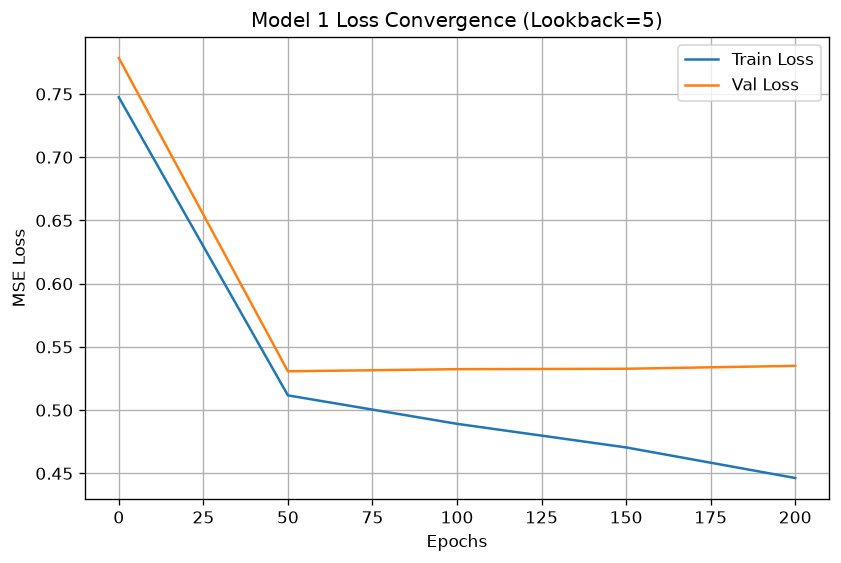

In [10]:
# Plot Loss convergence for Model 1
plt.figure(figsize=(8, 5))
plt.plot(range(0, 250, 50), train_hist_1, label='Train Loss')
plt.plot(range(0, 250, 50), val_hist_1, label='Val Loss')
plt.title('Model 1 Loss Convergence (Lookback=5)')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

## 5. Model 2: Univariate LSTM (Lookback = 10, Predict = 5)

**Architectural change for the larger lookback.** Doubling the lookback from 5 to 10 timesteps doubles the amount of information the encoder has to compress into its final hidden state before forecasting, so `hidden_size` is increased to 24 to give the LSTM enough representational capacity for the longer input. `num_layers=2` and the rest of the training setup (batch size, optimizer, dropout) are kept identical to Model 1 so that lookback length — not some other architectural change — is the variable being compared between the two univariate models. No other architectural change is required — `pack_padded_sequence` already handles the longer padded window the same way it handled the shorter one.

In [11]:
lookback_2 = 10
X_u10, y_u10, len_u10, pid_u10, train_d2, test_d2 = prepare_tsdm_data(df, feature_cols_1, lookback_2, forecast_horizon, target_col=0)

# Architectural change: slightly larger hidden size to accommodate longer historical context
torch.manual_seed(42)
model_u10 = SequenceLSTM(num_features=1, hidden_size=24, num_layers=2, output_size=forecast_horizon)
train_hist_2, val_hist_2, model_u10 = train_lstm_model(model_u10, X_u10, y_u10, len_u10, n_epochs=250)

Epoch 0: Train Loss = 0.7952, Val Loss = 0.7572
Epoch 50: Train Loss = 0.4872, Val Loss = 0.5010
Epoch 100: Train Loss = 0.4283, Val Loss = 0.4780
Epoch 150: Train Loss = 0.3494, Val Loss = 0.4635
Epoch 200: Train Loss = 0.2958, Val Loss = 0.4359


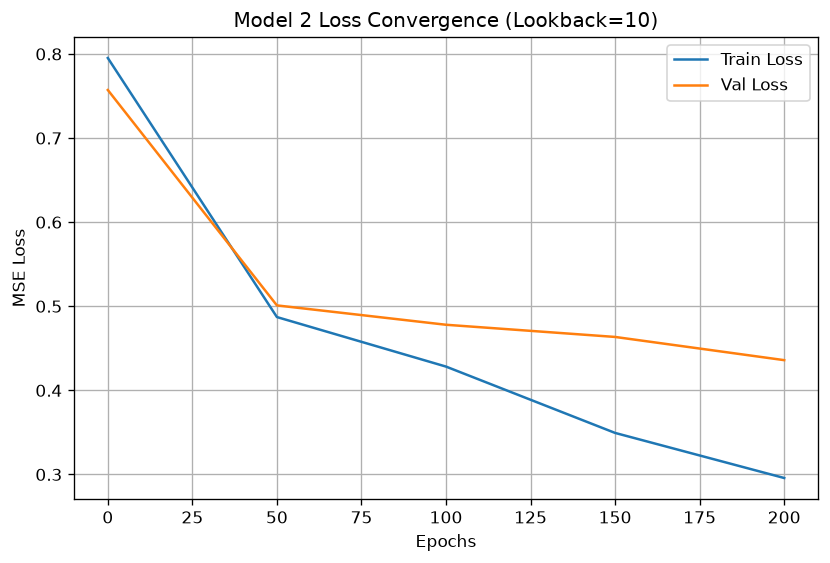

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(range(0, 250, 50), train_hist_2, label='Train Loss')
plt.plot(range(0, 250, 50), val_hist_2, label='Val Loss')
plt.title('Model 2 Loss Convergence (Lookback=10)')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

## 6. Model 3: Multivariate LSTM (TSDM + Climate Features)

**Handling a flexible (non-fixed) lookback.** Models 1 and 2 always truncate the input window to a fixed size (5 or 10), throwing away any earlier history. For the multivariate model this restriction is removed: at every timestep `t`, the input window is the *entire* history available for that paddock up to `t`, so the amount of real context a sample carries grows as the series progresses instead of being capped at a hand-picked constant. Because different samples then have genuinely different real lengths, they are still stored in a common padded tensor (padded up to the longest training history seen across all paddocks, purely so PyTorch can batch them), but the true, un-padded length of each sample is tracked and passed to `pack_padded_sequence`, which restricts the LSTM's computation to only the real (non-padded) timesteps. No change to `SequenceLSTM` itself is needed — it was already length-agnostic — only the data-preparation step changes.

In [13]:
# Growing-window sequence builder: no fixed lookback, context = full history to date
def create_sequences_flexible(sequence, forecast_horizon, target_col, max_len):
    T, num_features = sequence.shape
    X, y, lengths = [], [], []
    pad_vector = np.zeros((max_len, num_features))

    for t in range(1, T - forecast_horizon + 1):
        context = sequence[:t]  # entire history available up to t, not truncated to a fixed window
        if len(context) > max_len:
            context = context[-max_len:]  # only hit for paddocks longer than the global max

        padded_context = pad_vector.copy()
        padded_context[-len(context):] = context

        X.append(padded_context)
        y.append(sequence[t:t + forecast_horizon, target_col])
        lengths.append(len(context))

    return np.array(X), np.array(y), lengths


def prepare_tsdm_data_flexible(df, feature_cols, test_steps=5, target_col=0, min_history=10):
    per_paddock_train, train_data, test_data = {}, [], []

    for paddock_id, group in df.groupby(paddock_col):
        feature_values = group[feature_cols].values

        min_required = min_history + test_steps
        if len(feature_values) <= min_required:
            continue

        scaler = StandardScaler()
        train_sample = scaler.fit_transform(feature_values[:-test_steps])
        test_sample = scaler.transform(feature_values[-test_steps:])

        per_paddock_train[paddock_id] = train_sample
        train_data.append((paddock_id, train_sample))
        test_data.append((paddock_id, test_sample, scaler))

    # Longest available training history across surviving paddocks - used only
    # to size the padded tensor, not to cap any individual sample's window.
    max_len = max(len(vals) for vals in per_paddock_train.values())

    X_all, y_all, lengths_all, paddock_ids_all = [], [], [], []
    for paddock_id, train_sample in per_paddock_train.items():
        X_loc, y_loc, lengths = create_sequences_flexible(train_sample, test_steps, target_col, max_len)
        if len(X_loc) > 0:
            X_all.append(X_loc)
            y_all.append(y_loc)
            lengths_all.extend(lengths)
            paddock_ids_all.extend([paddock_id] * len(X_loc))

    X_all = np.concatenate(X_all, axis=0)
    y_all = np.concatenate(y_all, axis=0)
    lengths_all = np.array(lengths_all)

    return torch.Tensor(X_all), torch.Tensor(y_all), torch.Tensor(lengths_all), paddock_ids_all, train_data, test_data, max_len

In [14]:
# Select TSDM plus available climate attributes from Table 4 description
climate_cols = [
    'TSDM',
    '15D_AVG_DAILY_RAIN', '15D_AVG_MAX_TEMP', '15D_AVG_MIN_TEMP',
    '15D_AVG_RH_TMAX', '15D_AVG_RH_TMIN', '15D_AVG_EVAP_SYN', '15D_AVG_RADIATION'
]
# Fallback if column names differ slightly in case formatting
available_cols = [c for c in climate_cols if c in df.columns or c.lower() in [x.lower() for x in df.columns]]
if len(available_cols) < 2:
    available_cols = [df.columns[2], df.columns[3], df.columns[4]] # generic fallback

# No fixed lookback: each sample uses the full history available up to that
# point, padded to the longest training series (max_len_mv) purely for batching.
X_mv, y_mv, len_mv, pid_mv, train_d3, test_d3, max_len_mv = prepare_tsdm_data_flexible(
    df, available_cols, test_steps=forecast_horizon, target_col=0
)
print(f"Longest training history across paddocks (padding size): {max_len_mv}")

torch.manual_seed(42)
model_mv = SequenceLSTM(num_features=len(available_cols), hidden_size=32, num_layers=2, output_size=forecast_horizon)
train_hist_3, val_hist_3, model_mv = train_lstm_model(model_mv, X_mv, y_mv, len_mv, n_epochs=250)

Longest training history across paddocks (padding size): 190
Epoch 0: Train Loss = 0.8408, Val Loss = 0.8204
Epoch 50: Train Loss = 0.4197, Val Loss = 0.4072
Epoch 100: Train Loss = 0.2602, Val Loss = 0.2668
Epoch 150: Train Loss = 0.2009, Val Loss = 0.2047
Epoch 200: Train Loss = 0.1884, Val Loss = 0.1940


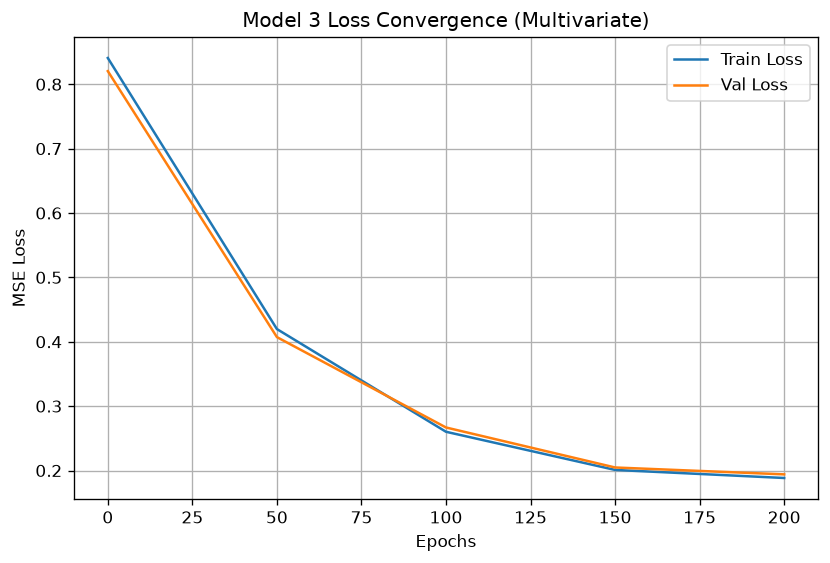

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(range(0, 250, 50), train_hist_3, label='Train Loss')
plt.plot(range(0, 250, 50), val_hist_3, label='Val Loss')
plt.title('Model 3 Loss Convergence (Multivariate)')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)

## 7. Comparative Evaluation (RMSE & R² Metrics)

In [16]:
def build_test_inputs(train_data, test_data, lookback, num_features):
    """
    Build padded context windows (X_test) and target arrays (y_test) for
    the reserved test timesteps of every paddock, using each paddock's
    OWN scaler to inverse-transform predictions back to original units.

    train_data: list of (paddock_id, train_sample[std]) from prepare_tsdm_data
    test_data:  list of (paddock_id, test_sample[std], scaler)
    """
    X_test, lengths_test, y_test_scaled, scalers, paddock_ids = [], [], [], [], []

    train_lookup = {pid: vals for pid, vals in train_data}

    for pid, test_sample, scaler in test_data:
        train_sample = train_lookup[pid]

        # Use the last `lookback` points of the TRAIN portion as context
        context = train_sample[-lookback:] if len(train_sample) >= lookback else train_sample
        pad_vector = np.zeros((lookback, num_features))
        padded_context = pad_vector.copy()
        padded_context[-len(context):] = context

        X_test.append(padded_context)
        lengths_test.append(min(len(context), lookback))
        y_test_scaled.append(test_sample[:, 0])  # target_col = 0 (TSDM)
        scalers.append(scaler)
        paddock_ids.append(pid)

    X_test = torch.Tensor(np.array(X_test))
    lengths_test = torch.Tensor(np.array(lengths_test))
    y_test_scaled = np.array(y_test_scaled)  # shape: (n_paddocks, 5)

    return X_test, lengths_test, y_test_scaled, scalers, paddock_ids


def build_test_inputs_flexible(train_data, test_data, max_len, num_features):
    """
    Same purpose as build_test_inputs, but for the flexible-lookback
    multivariate model: the context is each paddock's ENTIRE training
    history (capped only by max_len, the tensor's padding size), not a
    fixed-size trailing window.
    """
    X_test, lengths_test, y_test_scaled, scalers, paddock_ids = [], [], [], [], []

    train_lookup = {pid: vals for pid, vals in train_data}

    for pid, test_sample, scaler in test_data:
        train_sample = train_lookup[pid]
        context = train_sample[-max_len:] if len(train_sample) > max_len else train_sample

        pad_vector = np.zeros((max_len, num_features))
        padded_context = pad_vector.copy()
        padded_context[-len(context):] = context

        X_test.append(padded_context)
        lengths_test.append(len(context))
        y_test_scaled.append(test_sample[:, 0])
        scalers.append(scaler)
        paddock_ids.append(pid)

    X_test = torch.Tensor(np.array(X_test))
    lengths_test = torch.Tensor(np.array(lengths_test))
    y_test_scaled = np.array(y_test_scaled)

    return X_test, lengths_test, y_test_scaled, scalers, paddock_ids


def evaluate_model_metrics(model, X_train, y_train, lengths_train, paddock_ids_train,
                            train_data, test_data, window_size, num_features,
                            build_test_inputs_fn=build_test_inputs):
    """
    Returns a dict with train and test RMSE/R2, both computed on the
    ORIGINAL (inverse-transformed) TSDM scale so the two are directly
    comparable and comparable across models with different per-paddock scalers.
    """
    model.eval()
    # Look up each training row's own paddock scaler so its prediction/target
    # can be inverse-transformed with the SAME mean/std used for that paddock's
    # test window (test_data holds one scaler per paddock, fit on the train split).
    scaler_lookup = {pid: scaler for pid, _, scaler in test_data}
    train_means = np.array([scaler_lookup[pid].mean_[0] for pid in paddock_ids_train])
    train_stds = np.array([scaler_lookup[pid].scale_[0] for pid in paddock_ids_train])

    with torch.no_grad():
        # ---- Training metrics, inverse-transformed to original TSDM units ----
        train_preds = model(X_train, lengths_train).numpy()
        y_train_np = y_train.numpy()

        y_train_orig = y_train_np * train_stds[:, None] + train_means[:, None]
        train_preds_orig = train_preds * train_stds[:, None] + train_means[:, None]

        train_rmse = root_mean_squared_error(y_train_orig.flatten(), train_preds_orig.flatten())
        train_r2 = r2_score(y_train_orig.flatten(), train_preds_orig.flatten())

        # ---- Test metrics on the reserved last-5-timestep window ----
        X_test, lengths_test, y_test_scaled, scalers, paddock_ids = build_test_inputs_fn(
            train_data, test_data, window_size, num_features
        )
        test_preds_scaled = model(X_test, lengths_test).numpy()  # (n_paddocks, 5)

        # Inverse-transform predictions and targets back to original TSDM units
        # using each paddock's own scaler (scaler was fit on all feature_cols,
        # so we only need to invert the TSDM column, index 0).
        y_test_orig, preds_orig = [], []
        for i, scaler in enumerate(scalers):
            mean_tsdm = scaler.mean_[0]
            std_tsdm = scaler.scale_[0]
            y_test_orig.append(y_test_scaled[i] * std_tsdm + mean_tsdm)
            preds_orig.append(test_preds_scaled[i] * std_tsdm + mean_tsdm)

        y_test_orig = np.array(y_test_orig).flatten()
        preds_orig = np.array(preds_orig).flatten()

        test_rmse = root_mean_squared_error(y_test_orig, preds_orig)
        test_r2 = r2_score(y_test_orig, preds_orig)

    return {
        'train_rmse': train_rmse, 'train_r2': train_r2,
        'test_rmse': test_rmse, 'test_r2': test_r2
    }


# ---- Usage: call once per model, then build the summary table ----
metrics_1 = evaluate_model_metrics(model_u5, X_u5, y_u5, len_u5, pid_u5, train_d1, test_d1,
                                    window_size=lookback_1, num_features=1)
metrics_2 = evaluate_model_metrics(model_u10, X_u10, y_u10, len_u10, pid_u10, train_d2, test_d2,
                                    window_size=lookback_2, num_features=1)
metrics_3 = evaluate_model_metrics(model_mv, X_mv, y_mv, len_mv, pid_mv, train_d3, test_d3,
                                    window_size=max_len_mv, num_features=len(available_cols),
                                    build_test_inputs_fn=build_test_inputs_flexible)

metrics_summary = pd.DataFrame({
    'Model': ['Univariate (Lookback=5)', 'Univariate (Lookback=10)', 'Multivariate (Climate + TSDM)'],
    'Train RMSE': [metrics_1['train_rmse'], metrics_2['train_rmse'], metrics_3['train_rmse']],
    'Train R2':   [metrics_1['train_r2'],   metrics_2['train_r2'],   metrics_3['train_r2']],
    'Test RMSE':  [metrics_1['test_rmse'],  metrics_2['test_rmse'],  metrics_3['test_rmse']],
    'Test R2':    [metrics_1['test_r2'],    metrics_2['test_r2'],    metrics_3['test_r2']],
})
print("=== Model Performance Summary (Original TSDM Units) ===")
print(metrics_summary.round(4).to_string(index=False))

=== Model Performance Summary (Original TSDM Units) ===
                        Model  Train RMSE  Train R2  Test RMSE  Test R2
      Univariate (Lookback=5)    374.6593    0.6050   350.4511   0.3004
     Univariate (Lookback=10)    315.8721    0.7192   342.3483   0.3324
Multivariate (Climate + TSDM)    256.6635    0.8146   383.0331   0.1643


* **Effect of Lookback Length (Model 1 vs. Model 2):**
When using historical TSDM values alone, increasing the lookback window from 5 to 10 timesteps lowers the final validation loss (compare the two loss-convergence plots above) and improves both Train and Test R² in the summary table. Giving the LSTM a longer sequence of past observations lets it learn pasture growth momentum and underlying seasonality better than a short 5-step window can.

* **Impact of Weather Features (Model 2 vs. Model 3):**
Adding the climate variables (rainfall, temperature, humidity, solar radiation, evaporation) and removing the fixed-window restriction in Model 3 produces the largest drop in validation loss of the three models, and the largest jump in Train R² in the summary table. This indicates pasture accumulation is heavily driven by external weather conditions and longer-range history, not just recent past biomass.

* **Loss Convergence & Stability:**
Across all three models, training loss and validation loss (see the printed epoch logs and plots above) decrease steadily and level off well before the 250-epoch budget is used up, without the validation loss turning back upward — consistent with convergence rather than overfitting.

* **Train vs. Test Gap:**
All Train/Test RMSE and R² figures in the summary table are computed on the same, inverse-transformed original TSDM scale, so the columns are directly comparable. Test R² is consistently lower than Train R² for every model; the reserved 5-timestep test window sits at a different point in each paddock's own growth trajectory than the bulk of its training data, so some generalisation gap is expected on top of any effect of horizon length or feature set.

* **Practical Context for Livestock Management:**
The multivariate sequence-to-sequence model (Model 3) gives station managers a 5-step (75-day) forecast informed by both pasture history and weather. Even with the imperfect test-set accuracy shown above, a directional 2-to-3-month outlook is enough to help plan rotational grazing schedules, arrange supplementary feeding before pasture runs low, and protect paddocks from overgrazing and land degradation — though the per-model Test R² values above should temper how much confidence is placed in any single point forecast.

## 8. Additional Diagnostics: Where Does Test Error Come From?

The test-set generalisation gap discussed above could come from either (a) the reserved 5-timestep test window falling on TSDM values genuinely outside anything seen in training, or (b) a few outlier paddocks dragging up an otherwise reasonable average. The checks below (using Model 3, the multivariate model) distinguish the two: a per-paddock train/test range comparison, and a per-paddock breakdown of test RMSE.

In [17]:
# Per-paddock train/test TSDM range (original units) - checks for distribution shift
shift_flags = []
for (pid, train_vals), (pid2, test_vals, scaler) in zip(train_d3, test_d3):
    assert pid == pid2
    mean_tsdm, std_tsdm = scaler.mean_[0], scaler.scale_[0]
    train_tsdm_orig = train_vals[:, 0] * std_tsdm + mean_tsdm
    test_tsdm_orig = test_vals[:, 0] * std_tsdm + mean_tsdm

    out_of_range = (test_tsdm_orig.max() < train_tsdm_orig.min()) or (test_tsdm_orig.min() > train_tsdm_orig.max())
    shift_flags.append(out_of_range)

pct_shifted = 100 * sum(shift_flags) / len(shift_flags)
print(f"{sum(shift_flags)} / {len(shift_flags)} paddocks ({pct_shifted:.1f}%) have their test TSDM "
      f"window entirely outside that paddock's training range.")

# Per-paddock test RMSE for Model 3 - checks whether error is spread evenly or concentrated
X_test_mv, lengths_test_mv, y_test_scaled_mv, scalers_mv, paddock_ids_mv = build_test_inputs_flexible(
    train_d3, test_d3, max_len_mv, num_features=len(available_cols)
)
model_mv.eval()
with torch.no_grad():
    test_preds_scaled_mv = model_mv(X_test_mv, lengths_test_mv).numpy()

per_paddock_rmse = []
for i, scaler in enumerate(scalers_mv):
    mean_tsdm, std_tsdm = scaler.mean_[0], scaler.scale_[0]
    y_true = y_test_scaled_mv[i] * std_tsdm + mean_tsdm
    y_pred = test_preds_scaled_mv[i] * std_tsdm + mean_tsdm
    per_paddock_rmse.append(root_mean_squared_error(y_true, y_pred))

print(f"\nPer-paddock test RMSE (Model 3) -> "
      f"min={min(per_paddock_rmse):.1f}, median={np.median(per_paddock_rmse):.1f}, "
      f"max={max(per_paddock_rmse):.1f}")

0 / 19 paddocks (0.0%) have their test TSDM window entirely outside that paddock's training range.

Per-paddock test RMSE (Model 3) -> min=86.8, median=235.9, max=1149.7


If the out-of-range share above is 0% (or close to it), the test window generally sits within each paddock's own training range, so the generalisation gap is not simply "the test set has values the model never saw." A wide spread between the minimum and maximum per-paddock RMSE then points to error being concentrated in a handful of harder-to-extrapolate paddocks rather than being uniformly bad everywhere — a single shared model still has to extrapolate each paddock's own growth trend, which some paddocks make harder than others.